**LangChain Deep Technical Guide: Building Modular LLM Applications with Python**

What is LangChain?

LangChain is an open-source framework designed to simplify the development of applications powered by Large Language Models (LLMs). Instead of writing scattered API calls, LangChain lets you compose intelligent systems using modular components.

Why is LangChain Important?

Modern LLM applications are no longer just “input → output”. They require:

Context retention (memory)
Multi-step reasoning (chains)
External data access (tools)
Decision-making (agents)

LangChain provides a structured orchestration layer to handle all of this.

**Core Components of LangChain**

1. LLMs and Chat Models
Concept

LLMs generate text responses. Chat models are optimized for conversational interaction.

Why it exists

To abstract different providers (OpenAI, HuggingFace) into a unified interface.

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7
)

response = llm.invoke("Explain AI in simple terms")
print(response.content)

2. Prompt Templates

Concept

Templates structure inputs dynamically.

Why it exists

Avoid hardcoding prompts and enable reuse.

In [ ]:
from langchain.prompts import PromptTemplate

template = PromptTemplate(
    input_variables=["topic"],
    template="Explain {topic} in simple terms"
)

prompt = template.format(topic="Machine Learning")
print(prompt)

3. Chains

Concept

Chains combine multiple steps into a pipeline.

Why it exists

To handle sequential workflows automatically.


In [ ]:
from langchain.chains import LLMChain

chain = LLMChain(llm=llm, prompt=template)

result = chain.invoke({"topic": "Neural Networks"})
print(result["text"])

4. Memory

Concept

Stores conversation history.

Why it exists

To enable context-aware responses.

In [ ]:
from langchain.memory import ConversationBufferMemory
from langchain.chains import ConversationChain

memory = ConversationBufferMemory()

conversation = ConversationChain(
    llm=llm,
    memory=memory
)

print(conversation.predict(input="Hi"))
print(conversation.predict(input="What did I just say?"))

5. Agents

Concept

Agents decide what action to take dynamically.

Why it exists

To enable reasoning + tool usage.

In [ ]:
from langchain.agents import initialize_agent, Tool
from langchain.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

tools = [
    Tool(
        name="Search",
        func=search.run,
        description="Search the internet"
    )
]

agent = initialize_agent(
    tools,
    llm,
    agent="zero-shot-react-description",
    verbose=True
)

agent.run("Latest AI trends")

6. Tools

Concept

External capabilities (search, calculator, APIs).

Why it exists

LLMs alone cannot fetch real-time or external data.

7 Document Loaders

Concept

Load data from PDFs, text files, etc.

In [ ]:
from langchain.document_loaders import TextLoader

loader = TextLoader("sample.txt")
documents = loader.load()

8. Vector Stores (Indexes)

Concept

Store embeddings for semantic search.

Why it exists

To enable retrieval-based QA.

In [ ]:
from langchain.vectorstores import FAISS
from langchain.embeddings import OpenAIEmbeddings

embeddings = OpenAIEmbeddings()

db = FAISS.from_documents(documents, embeddings)
results = db.similarity_search("AI")

User Input → User provides query

Prompt Template → Formats input

LLM → Processes prompt

Chain → Handles workflow

Agent/Tool → Executes external actions
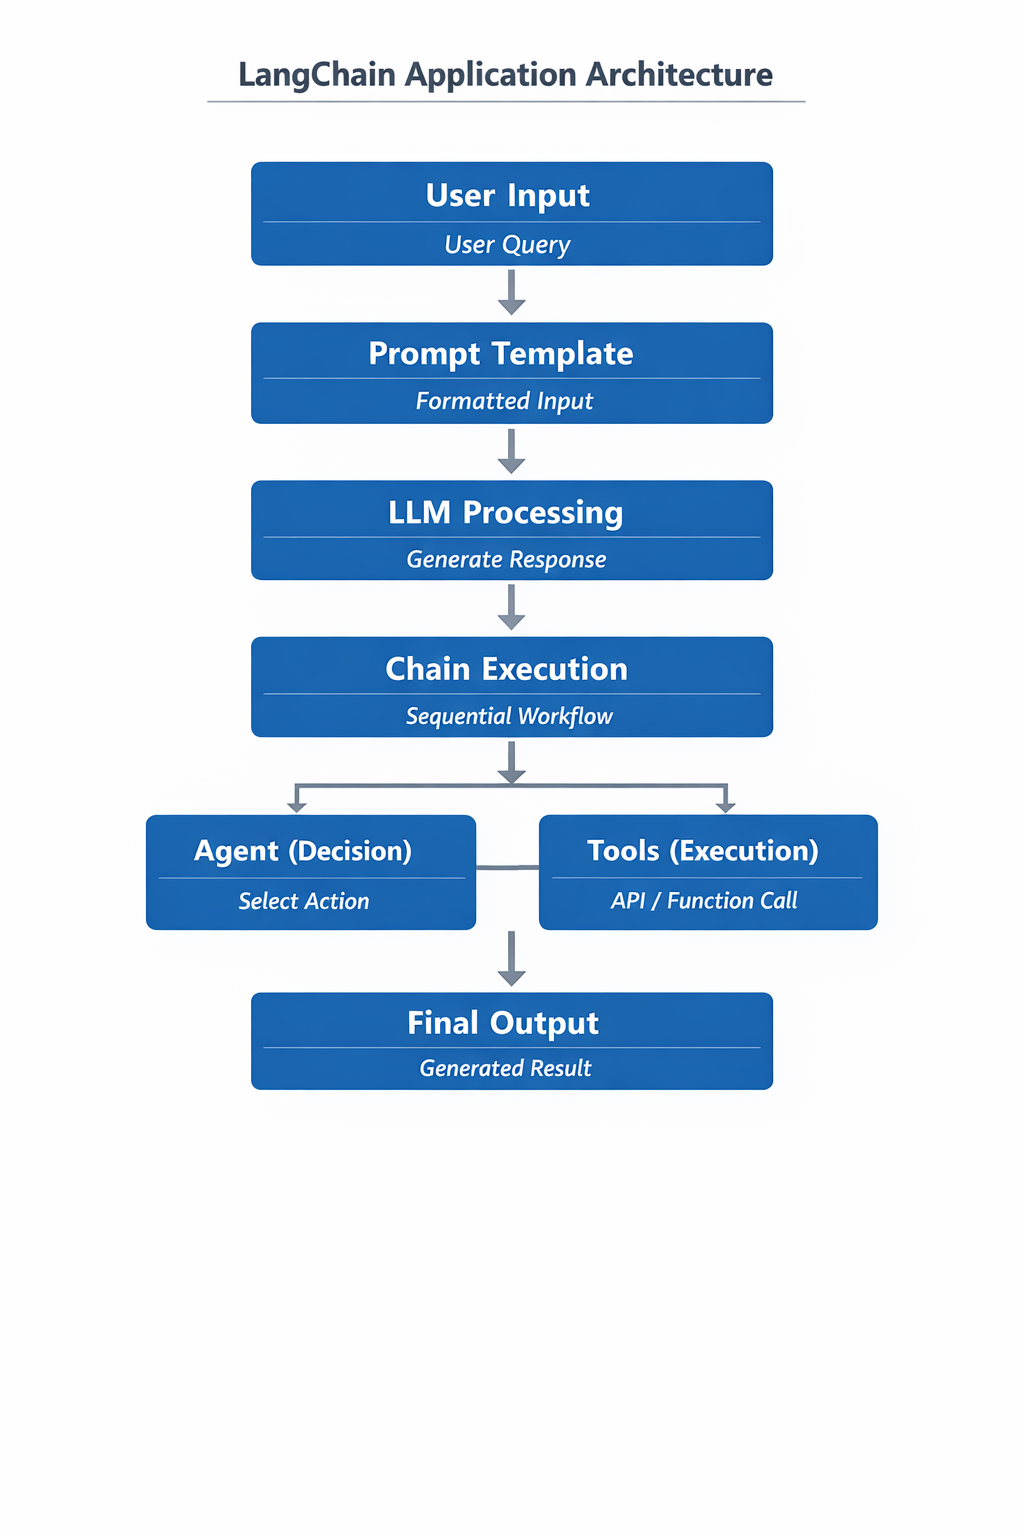
Output → Final response

In [ ]:
pip install langchain langchain-openai faiss-cpu duckduckgo-search

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

print(llm.invoke("What is Data Science?").content)

In [ ]:
from langchain.prompts import PromptTemplate

template = PromptTemplate(
    input_variables=["topic"],
    template="Explain {topic} like I'm a beginner"
)

In [ ]:
from langchain.chains import LLMChain

chain = LLMChain(llm=llm, prompt=template)

print(chain.invoke({"topic": "AI"})["text"])

In [ ]:
from langchain.memory import ConversationBufferMemory
from langchain.chains import ConversationChain

memory = ConversationBufferMemory()

chat = ConversationChain(llm=llm, memory=memory)

chat.predict(input="My name is Alex")
chat.predict(input="What is my name?")

In [ ]:
from langchain.agents import initialize_agent, Tool
from langchain.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

tools = [
    Tool(
        name="Search",
        func=search.run,
        description="Search for information"
    )
]

agent = initialize_agent(tools, llm, agent="zero-shot-react-description")

agent.run("Who won the latest cricket match?")

**Real-World Use Cases**

Use Case 1: AI Chatbot with Memory

Problem: Chatbots forget context

Solution: Use memory module

Components: LLM + Memory + Chain

Use Case 2: Document Q&A System (RAG)

Problem: Answer questions from documents

Solution: Use vector store + retriever

Components: Loader + Embeddings + FAISS + LLM

Use Case 3: AI Research Assistant

Problem: Fetch real-time info

Solution: Use agents + tools

Components: Agent + Search Tool + LLM

**Advantages**

Modular architecture

Rapid prototyping

Supports multiple LLM providers

Easy integration with tools

**Limitations**

Higher latency due to chaining

Debugging is complex

Cost increases with multiple calls

Overkill for simple applications

LangChain transforms LLM usage from isolated API calls into intelligent systems.

Key Takeaways:
It enables modular AI pipelines

Supports memory, agents, and tools

Ideal for real-world AI applications

Future Scope:
LangGraph for advanced workflows,
Multi-agent systems,
Autonomous AI applications.